# Transformer Quantization Benchmark: PyTorch vs OpenVINO

This notebook demonstrates how to benchmark the performance difference between a standard **PyTorch (FP32)** model and an optimized **OpenVINO (INT4)** model.

**We will cover:**
1. **Loading** a Large Language Model (Qwen2.5-0.5B).
2. **Benchmarking** the baseline latency in PyTorch.
3. **Optimizing** the model using NNCF (Neural Network Compression Framework) to INT4.
4. **Comparing** latency, throughput, and memory usage.

> **Note:** This benchmark focuses on the *generation phase* (latency per token) which is critical for chat applications.

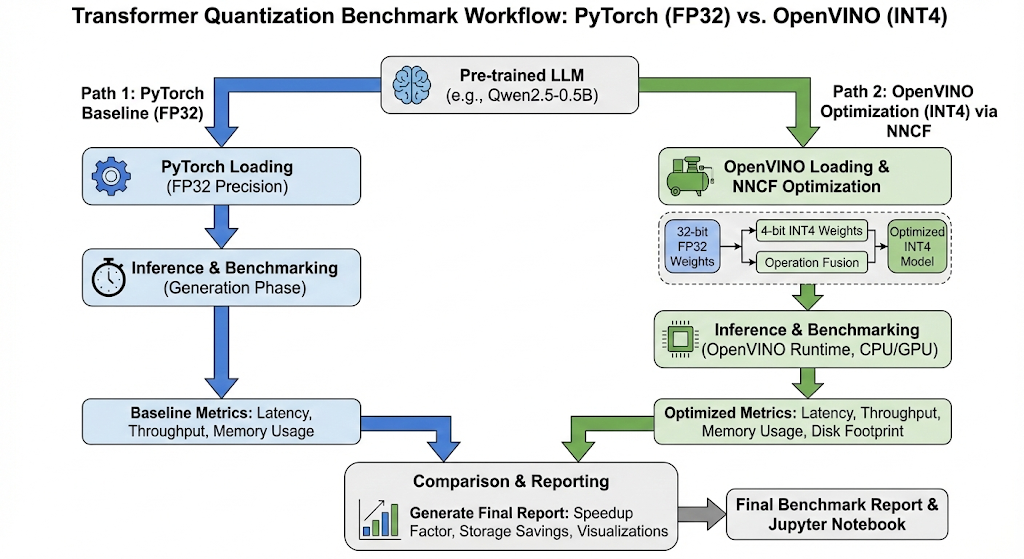

## 1. Environment Setup
We import the necessary libraries and load the configuration from `configs/benchmark_config.yaml`. We also validate that the runtime (OpenVINO + Torch) is correctly installed.

In [ ]:
import sys
import platform
import torch
import openvino as ov
from transformers import AutoTokenizer
from pathlib import Path

# Load our custom modules
from bench.model_loader import ModelFactory
from bench.runner import BenchmarkRunner
from bench.metrics import MetricsCollector
import yaml

# Load Config
with open("configs/benchmark_config.yaml", "r") as f:
    config = yaml.safe_load(f)

print(f"System: {platform.system()} {platform.release()}")
print(f"Python: {sys.version.split()[0]}")
print(f"OpenVINO: {ov.get_version()}")
print(f"Torch: {torch.__version__}")

# Check for Accelerators
core = ov.Core()
devices = core.available_devices
print(f" Available AI Accelerators: {devices}")
if "GPU" in devices:
    print(" iGPU Detected")
else:
    print(" No GPU found, using CPU only")

## 2. PyTorch Baseline (FP32)
We start by loading the model in its original **32-bit floating point** precision. This represents the standard "out-of-the-box" performance on a CPU.

In [ ]:
# Load PyTorch Model (FP32)


print(" Benchmarking PyTorch (Baseline)")
pt_model, tokenizer, pt_load_time , _  = ModelFactory.load_pytorch(config['model']['id'])

# Run Benchmark
pt_runner = BenchmarkRunner(pt_model, tokenizer, framework="pt")
pt_results = pt_runner.run(
    num_iters=config['benchmark']['measure_iterations'],
    warmup=config['benchmark']['warmup_iterations']
)

# Cleanup to save RAM for next phase
del pt_model, pt_runner
import gc; gc.collect()


## 3. OpenVINO Optimization (INT4)
Now we switch to OpenVINO. We use `OVModelForCausalLM` with `precision="int4"`.

**What happens here?**
* **NNCF** kicks in automatically.
* It analyzes the model weights.
* It groups them and maps them to a smaller 4-bit representation (Quantization).
* It fuses mathematical operations (like Add+Multiply) into a single step for speed.

In [ ]:
# Load OpenVINO Model (INT4)

print("\n Benchmarking OpenVINO (INT4)")
ov_model, tokenizer, ov_load_time, cache_path = ModelFactory.load_openvino(
    config['model']['id'], 
    precision=config['export']['precision']
)

# Run Benchmark
ov_runner = BenchmarkRunner(ov_model, tokenizer, framework="ov")
ov_results = ov_runner.run(
    num_iters=config['benchmark']['measure_iterations'],
    warmup=config['benchmark']['warmup_iterations']
)


## 4. Benchmark Results & Visualization

In this final phase, we aggregate the data from both runs to generate a comprehensive performance report. We focus on four critical metrics for deployment:

1.  **Latency (P50):** The median time it takes to generate a single token. Lower is better for chat responsiveness.
2.  **Throughput:** The total number of tokens generated per second. Higher is better for batch processing.
3.  **RAM Usage:** The peak memory consumption during inference. Lower values allow running larger models on smaller devices.
4.  **Disk Footprint:** The physical storage size of the model. INT4 quantization significantly reduces this, saving disk space.


In [ ]:
# Calculate Disk Footprint
import pandas as pd

ov_disk_size = MetricsCollector.get_directory_size_mb(cache_path)

# Create DataFrame
results_df = pd.DataFrame([
    {
        "Backend": "PyTorch (FP32)", 
        "Latency P50 (ms)": pt_results["p50_ms"], 
        "Throughput (t/s)": pt_results["throughput_ips"],
        "RAM Usage (MB)": pt_results["ram_usage_mb"],
        "Disk Size (MB)": "N/A (Variable)"
    },
    {
        "Backend": f"OpenVINO ({config['export']['precision'].upper()})", 
        "Latency P50 (ms)": ov_results["p50_ms"], 
        "Throughput (t/s)": ov_results["throughput_ips"],
        "RAM Usage (MB)": ov_results["ram_usage_mb"],
        "Disk Size (MB)": round(ov_disk_size, 2)
    }
])

# Calculate Speedup
speedup = pt_results["p50_ms"] / ov_results["p50_ms"]

print("\n FINAL BENCHMARK RESULTS")
display(results_df)

print(f"\n Speedup Factor: {speedup:.2f}x")
print(f" Storage Savings: INT4 model is taking only {ov_disk_size:.2f} MB")

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Backend", y="Latency P50 (ms)", palette="viridis")
plt.title(f"Latency Comparison: {config['model']['id']}")
plt.ylabel("Latency (Lower is Better)")
plt.show()